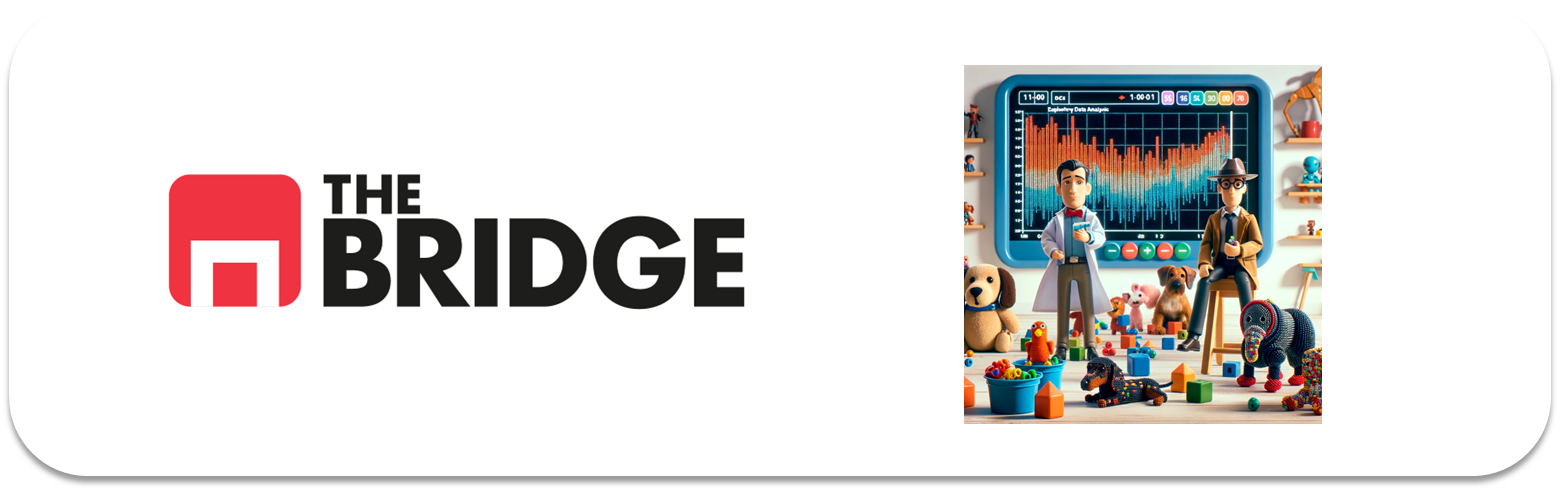

## PRACTICA OBLIGATORIA: **Análisis Multivariante**

* La práctica obligatoria de esta unidad consiste en completar el análisis del dataset del Titanic, dirigido por una serie de preguntas, y de terminar de analizar algunos aspectos del dataset de viajes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0


Importa los paquetes y módulos que necesites a lo largo del notebook

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from bootcampviztools import plot_categorical_numerical_relationship, plot_combined_graphs, \
    pinta_distribucion_categoricas, plot_grouped_boxplots, plot_categorical_relationship_fin, plot_grouped_histograms, \
        grafico_dispersion_con_correlacion, bubble_plot


## #1: Titanic

### #1.1

Carga en un dataframe el dataset del titanic, que está en la ruta "./data/titanic.csv".

In [70]:
df_titanic = pd.read_csv("./data/titanic.csv")
df_titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


### #1.2

Deshazte de las columnas "deck", "survived", "pclass" y "embarked" porque no las emplearemos, la primera por su cantidad de nulos y el resto porque son variantes de otras que ya existen y cuyos valores resultan más expresivos a la hora de hacer un análisis. 

In [71]:
df_titanic = df_titanic.drop(columns=["deck", "survived", "pclass", "embarked"])
df_titanic

,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone
0,male,22.0,1,0,7.2500,Third,man,True,Southampton,no,False
1,female,38.0,1,0,71.2833,First,woman,False,Cherbourg,yes,False
2,female,26.0,0,0,7.9250,Third,woman,False,Southampton,yes,True
3,female,35.0,1,0,53.1000,First,woman,False,Southampton,yes,False
4,male,35.0,0,0,8.0500,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...
886,male,27.0,0,0,13.0000,Second,man,True,Southampton,no,True
887,female,19.0,0,0,30.0000,First,woman,False,Southampton,yes,True
888,female,NaN,1,2,23.4500,Third,woman,False,Southampton,no,False
889,male,26.0,0,0,30.0000,First,man,True,Cherbourg,yes,True


### #1.3

Suma las columnas "parch" y "sibsp" para tener el número de parientes de cada pasajero, guarda el resultado en otra columna "family_members", luego deshazte de "parch" y "sibsp"

In [72]:
df_titanic["family_members"] = df_titanic["parch"] + df_titanic["sibsp"]

In [73]:
df_titanic = df_titanic.drop(columns=["parch", "sibsp"])
df_titanic

,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members
0,male,22.0,7.2500,Third,man,True,Southampton,no,False,1
1,female,38.0,71.2833,First,woman,False,Cherbourg,yes,False,1
2,female,26.0,7.9250,Third,woman,False,Southampton,yes,True,0
3,female,35.0,53.1000,First,woman,False,Southampton,yes,False,1
4,male,35.0,8.0500,Third,man,True,Southampton,no,True,0
...,...,...,...,...,...,...,...,...,...,...
886,male,27.0,13.0000,Second,man,True,Southampton,no,True,0
887,female,19.0,30.0000,First,woman,False,Southampton,yes,True,0
888,female,NaN,23.4500,Third,woman,False,Southampton,no,False,3
889,male,26.0,30.0000,First,man,True,Cherbourg,yes,True,0


### #1.4

Imputa la moda a los valores nulos de "embark_town"

In [74]:
df_titanic.isnull().sum()

sex                 0
age               177
fare                0
class               0
who                 0
adult_male          0
embark_town         2
alive               0
alone               0
family_members      0
dtype: int64

In [75]:
df_titanic["embark_town"] = df_titanic["embark_town"].fillna(df_titanic["embark_town"].mode()[0])

In [76]:
df_titanic.isnull().sum()

sex                 0
age               177
fare                0
class               0
who                 0
adult_male          0
embark_town         0
alive               0
alone               0
family_members      0
dtype: int64

### #1.5

Imputa la media a los valores faltantes de "age", si quieres puedes hacer algo más preciso (por ejemplo considerando además la columna "who")

In [77]:
df_titanic["age"] = df_titanic["age"].fillna(df_titanic.groupby(["who","class"])["age"].transform("mean"))

In [78]:
df_titanic.isnull().sum()

sex               0
age               0
fare              0
class             0
who               0
adult_male        0
embark_town       0
alive             0
alone             0
family_members    0
dtype: int64

### #1.6

Realiza los análisis bivariantes o multivariantes que necesites, así como los test de hipótesis necesarios para contestar a las siguientes preguntas. Nota: utiliza la variable "alive" para saber si un pasajero sobrevivió o no:

1. En términos absolutos, ¿sobrevivieron más hombres, mujeres o niños? ¿Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre el sexo y la supervivencia en el Titanic?¿Y entre ser adulto o ser niño?

2. En términos absolutos, ¿de que clase sobrevivieron más pasajeros?¿ Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre la clase en la que se viajaba y la supervivencia?

3. ¿De qué ciudad sobrevivieron más personas?¿Y porcentualmente de que ciudad sobrevivieron más personas? ¿Hay alguna relación estadística significativa entre haber embarcado en una de las tres ciudades y haber sobrevivido o fallecido?

4. ¿Qué relación hay entre el precio del pasaje y la supervivencia/fallecimiento?

5. Existen pasajero que no pagaron el billete, ¿podrías explicar por qué? ¿Qué ocurrió con la persona que más dinero se dejó?

6. Existe alguna relación entre el dinero pagado, la ciudad de embarque y la superviviencia/fallecimiento. No necesitas aplicar ningún test, muestralo numérica o visualmente.

7. Ahondando en la relación entre sobrevivir o fallecer, la clase en la que se viajó y la edad de los pasajeros. ¿Qué agrupación de las dos variables (clase y edad) sobrevivió más en términos absolutos y en términos relativos?

8. Finalmente, muestra las posibles relaciones entre edad, coste del billete y supervivencia/fallecimiento. ¿Qué puedes decir al respecto?

### 1

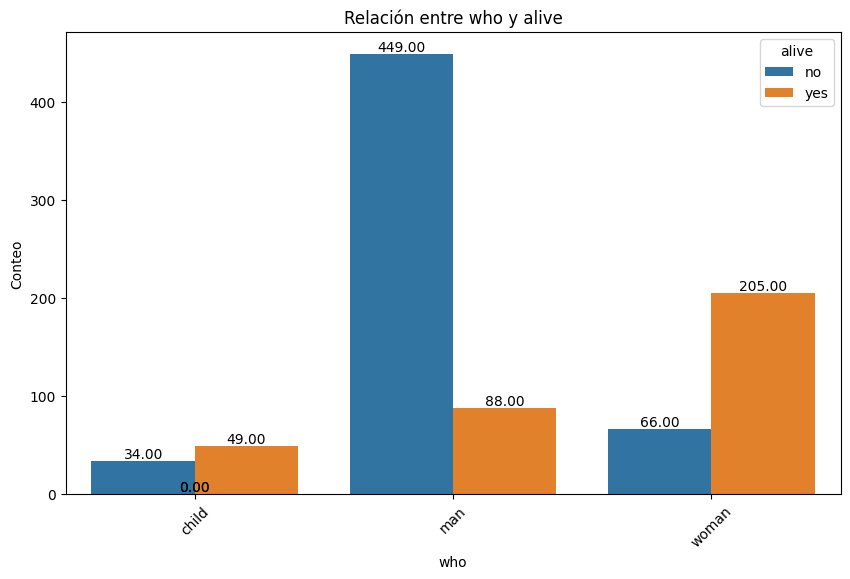

In [79]:
plot_categorical_relationship_fin(df_titanic, "who", "alive", show_values=True)

En terminos absolutos podemos decir observando el gráfico que sobrevivieron más mujeres(205), luego hombres(88) y por último niños(49).

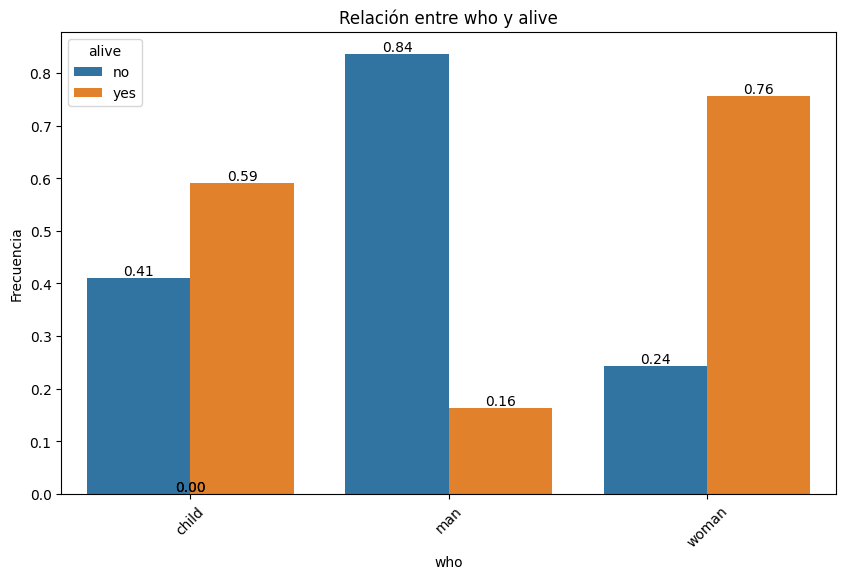

In [80]:
plot_categorical_relationship_fin(df_titanic, "who", "alive", relative_freq=True, show_values=True)

En términos relativos las mujeres siguen siendo las que más sobrevivieron(76%), luego van los niños(59%) y por último los hombre(16%)

#### Para calcular la relación estadística de las 2 variables voy a aplicar el tes de Chi-Cuadradado

In [81]:
tabla_contigencia = pd.crosstab(df_titanic["alive"], df_titanic["sex"])
tabla_contigencia

sex,female,male
alive,,
no,81,468
yes,233,109


In [82]:
from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(tabla_contigencia)

print("Valor Chi-Cuadrado:", chi2)
print("P_Value:", p)
print("Grados de Libertad", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 260.71702016732104
P_Value: 1.1973570627755645e-58
Grados de Libertad 1
Tabla de Frecuencias Esperadas:
 [[193.47474747 355.52525253]
 [120.52525253 221.47474747]]


 Con un p-valor tan extremadamente pequeño se puede afirmar con total contundencia que la relación entre sexo y supervivencia es estadísticamente significativa.

In [83]:
df_titanic["adulto"] = (df_titanic["who"] == "woman") | (df_titanic["who"] == "man")
tabla_contigencia = pd.crosstab(df_titanic["alive"], df_titanic["adulto"])
tabla_contigencia

adulto,False,True
alive,,
no,34,515
yes,49,293


In [84]:
from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(tabla_contigencia)

print("Valor Chi-Cuadrado:", chi2)
print("P_Value:", p)
print("Grados de Libertad", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 15.556993340077092
P_Value: 8.005497211300105e-05
Grados de Libertad 1
Tabla de Frecuencias Esperadas:
 [[ 51.14141414 497.85858586]
 [ 31.85858586 310.14141414]]


Con estos datos vemos que el ser adulto o niño también esta estadísticamente relacionado con la supervivencia aunque no con tanta fuerza como el sexo.

En resumen en sexo es el factor más determinante de los dos para la supervivencia en el Titanic.

### 2

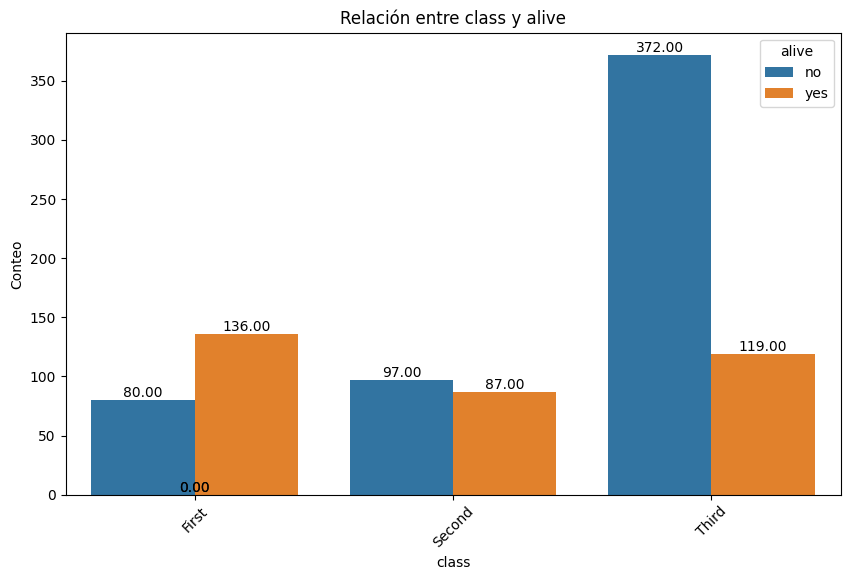

In [85]:
plot_categorical_relationship_fin(df_titanic, "class", "alive", show_values=True)

Observando el gráfico podemos observar que en terminos absolutos se salvaron más pasajeros de primera clase(136), seguidos de tercera clase(119) y por último de segunda clase(87)

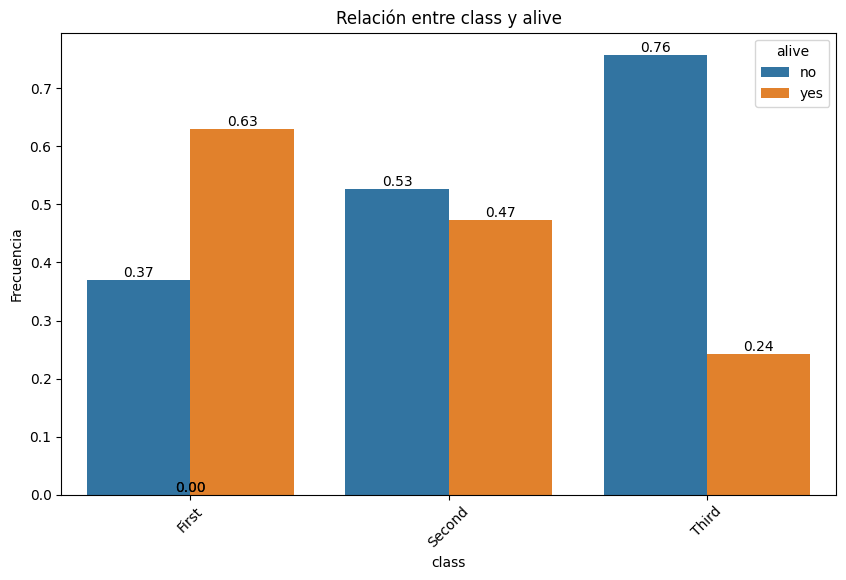

In [86]:
plot_categorical_relationship_fin(df_titanic, "class", "alive", relative_freq=True, show_values=True)

En terminos relativos observamos que la clase con más supervivencia fué la primera clase con un 63%, seguido de la segunda clase con un 47% y por último la tercera clase con solo un 24% (Aquí podemos observar que aunque lo valores absolutos de la tercera clase no distaban mucho de la primera clase en valor relativo vemos que la diferencia en grandísima)
Con lo cual ya podemos ver que la clase era un factor determinante para la supervivencia.

#### Para calular la relación estadística de las 2 variables voy a realizar el test de Chi-Cuadrado

In [87]:
tabla_contigencia = pd.crosstab(df_titanic["alive"], df_titanic["class"])
tabla_contigencia

class,First,Second,Third
alive,,,
no,80,97,372
yes,136,87,119


In [88]:
from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(tabla_contigencia)

print("Valor Chi-Cuadrado:", chi2)
print("P_Value:", p)
print("Grados de Libertad", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 102.88898875696056
P_Value: 4.549251711298793e-23
Grados de Libertad 2
Tabla de Frecuencias Esperadas:
 [[133.09090909 113.37373737 302.53535354]
 [ 82.90909091  70.62626263 188.46464646]]


Como ya sospechabamos existe una gran relación estadística entre la clase y la supervivencia.

La clase en que viajabas era un factor importante para la supervivencia.

### 3

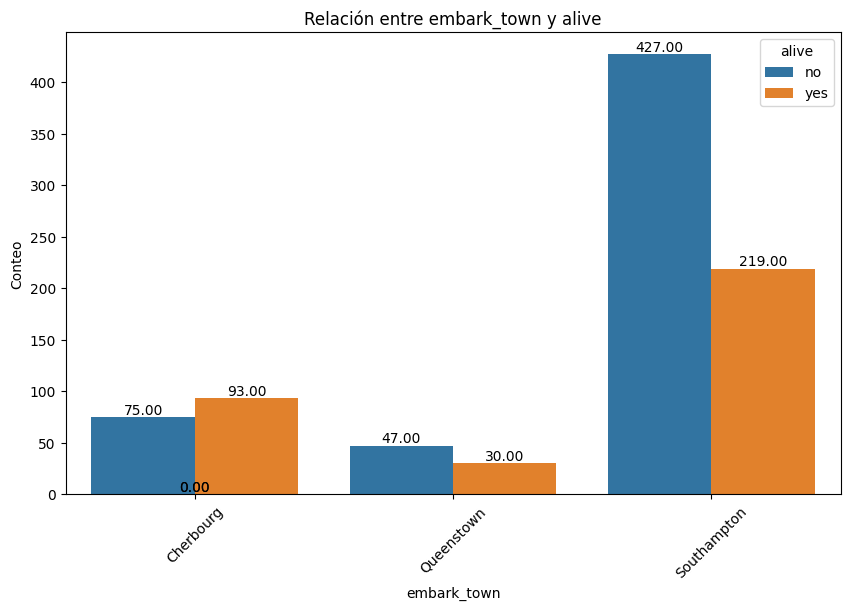

In [89]:
plot_categorical_relationship_fin(df_titanic, "embark_town", "alive", show_values=True)

La ciudad con más supervivientes en valores absolutos fue claramente Southampton(219), seguida de Cherbourg(93) y por último Queesntown(30)

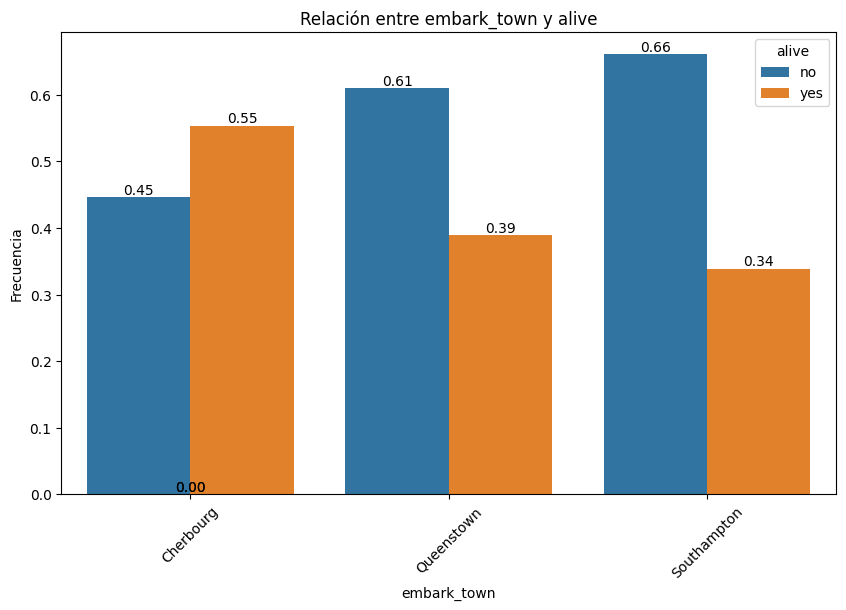

In [90]:
plot_categorical_relationship_fin(df_titanic, "embark_town", "alive", relative_freq=True, show_values=True)

La ciudad con mayor porcentaje de supervivencia fue Cherbourg con un 55%, seguida por Queenstown con un 39% y por último Southampton con un 34%(Este porcentaje se debe a que fué la ciudad donde más pasajeros embarcaron, por eso está la última en porcentaje de supervivientes aunque está la primera en número de supervivientes)

#### Para calular la relación estadística de las 2 variables voy a realizar el test de Chi-Cuadrado

In [91]:
tabla_contigencia = pd.crosstab(df_titanic["alive"], df_titanic["embark_town"])
tabla_contigencia

embark_town,Cherbourg,Queenstown,Southampton
alive,,,
no,75,47,427
yes,93,30,219


In [92]:
from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(tabla_contigencia)

print("Valor Chi-Cuadrado:", chi2)
print("P_Value:", p)
print("Grados de Libertad", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 25.964452881874784
P_Value: 2.3008626481449577e-06
Grados de Libertad 2
Tabla de Frecuencias Esperadas:
 [[103.51515152  47.44444444 398.04040404]
 [ 64.48484848  29.55555556 247.95959596]]


Con este valor bajo de p_value podemos determinar que hay una relación estadística entre la ciudad de embarked y la supervivencia.

### 4

Primero vamos a ver la distribución de valores por separado de cada variable

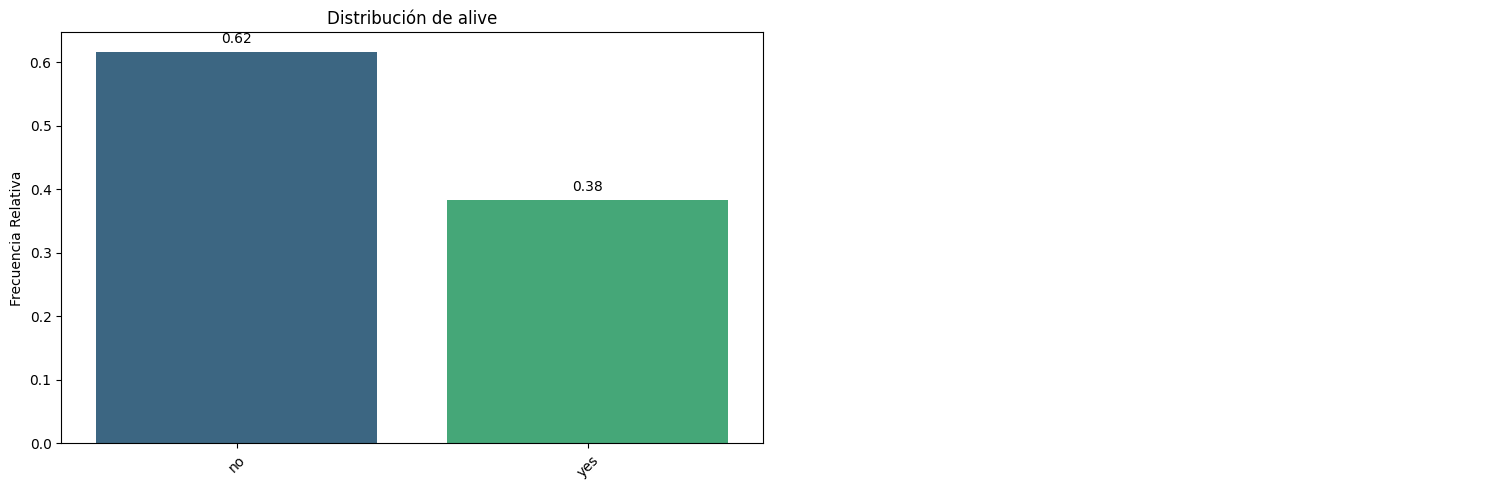

In [93]:
pinta_distribucion_categoricas(df_titanic, ["alive"], relativa=True, mostrar_valores=True)

(2,)


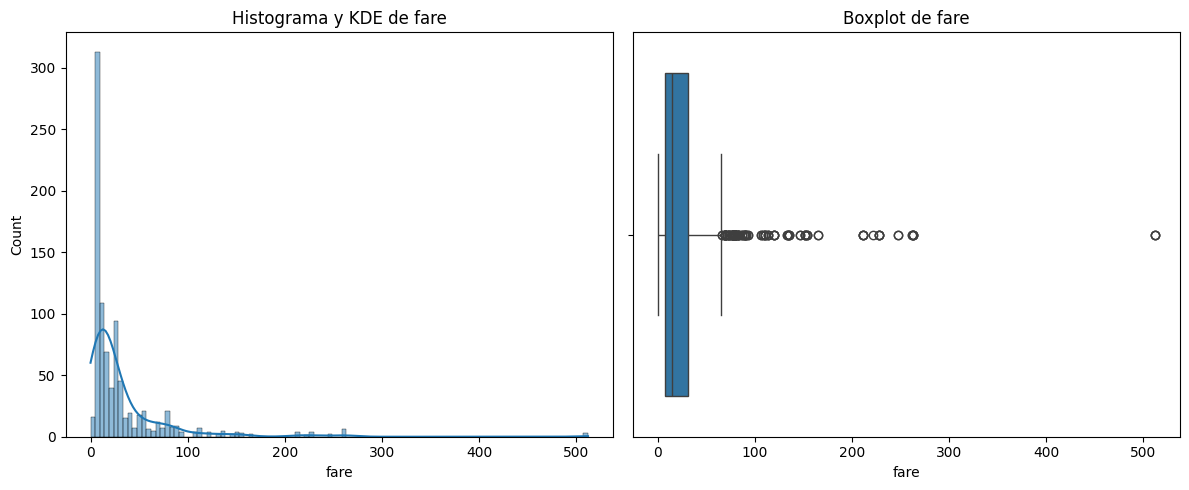

In [94]:
plot_combined_graphs(df_titanic, ["fare"])

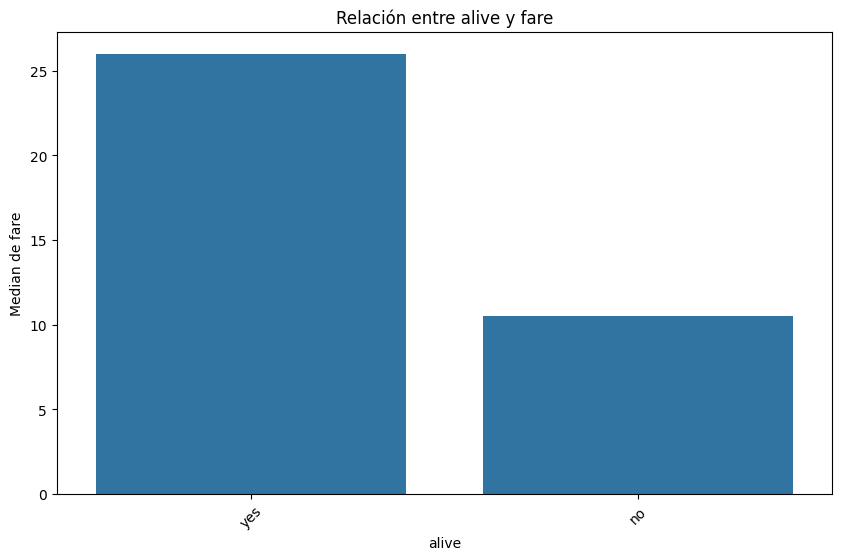

In [95]:
plot_categorical_numerical_relationship(df_titanic, "alive", "fare", measure="median")

En este gráfico donde estamos comparando la media de 'fare' con los valores de 'alive' ya podemos observar que hay una gran diferencia entre un valor y otro por lo que podemos ir deduciendo que hay dependencia entre las 2 variables. 
Ya podemos ir viendo que a mayor precio del pasaje mayor supervivencia.

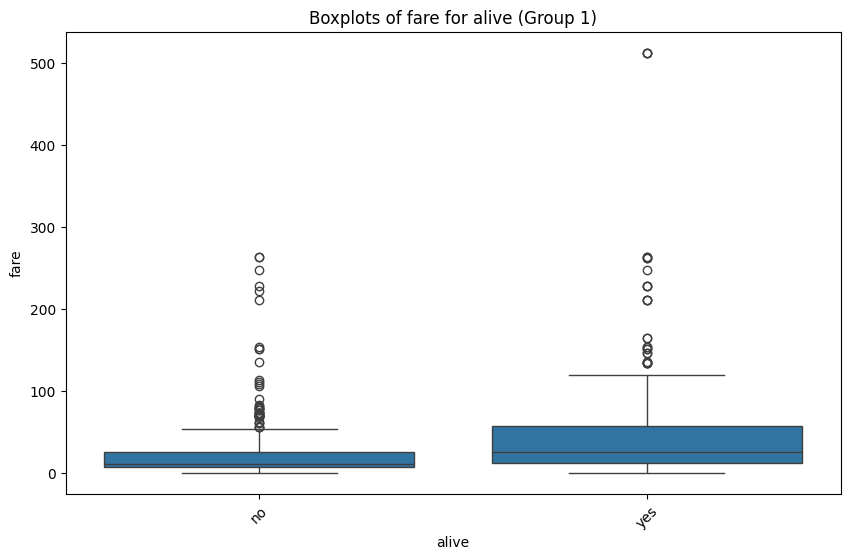

In [96]:
plot_grouped_boxplots(df_titanic, "alive", "fare")

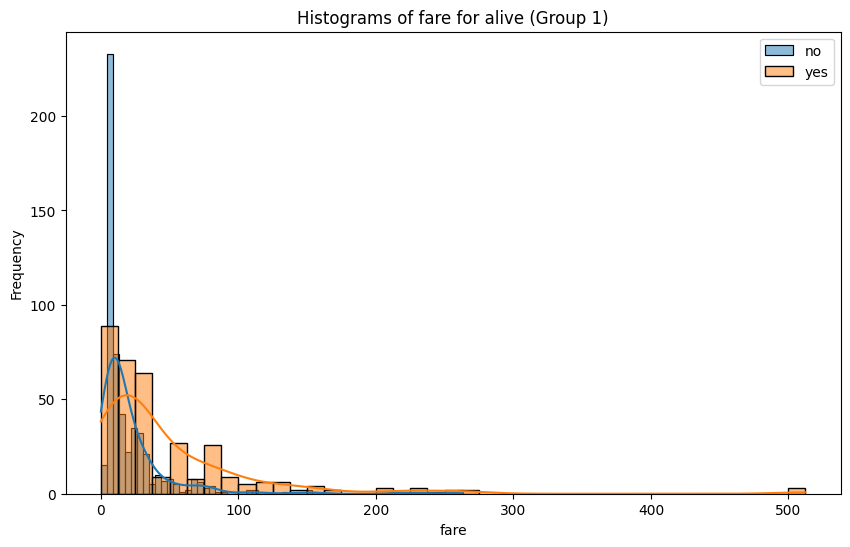

In [97]:
plot_grouped_histograms(df_titanic, "alive", "fare", 2)

En estos 2 gráficos en los que podemos comparar los diagramas de cajas y histrogramas de las 2 variables podemos observar que son bástantes diferentes para cada una de las variables, lo que nos indica la depencia que existe entre ellas.

Por último para poder determinar con exactitud la dependencia que estamos obsevando voy a realizar un test U de Mann-Whitney

In [98]:
from scipy.stats import mannwhitneyu

grupo_a = df_titanic.loc[df_titanic.alive == "yes"]["fare"]
grupo_b = df_titanic.loc[df_titanic.alive == "no"]["fare"]

In [99]:
u_stat, p_valor = mannwhitneyu(grupo_a, grupo_b)
print("Estadístico U:", u_stat)
print("Valor_p", p_valor)

Estadístico U: 129951.5
Valor_p 4.553477179250237e-22


Con el valor_p tan bajo podemos afirmar que hay una relación estadística entre el precio de los pasajes y la supervivencia. 

A mayor precio del pasaje mayor supervivencia, lo que tiene relación con lo que ya vimos de pasajeros de primera clase y supervivencia.

### 5

In [100]:
df_cero_pasaje = df_titanic[df_titanic["fare"] == 0]
df_cero_pasaje

,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members,adulto
179,male,36.000000,0.0,Third,man,True,Southampton,no,True,0,True
263,male,40.000000,0.0,First,man,True,Southampton,no,True,0,True
271,male,25.000000,0.0,Third,man,True,Southampton,yes,True,0,True
277,male,33.588889,0.0,Second,man,True,Southampton,no,True,0,True
302,male,19.000000,0.0,Third,man,True,Southampton,no,True,0,True
413,male,33.588889,0.0,Second,man,True,Southampton,no,True,0,True
466,male,33.588889,0.0,Second,man,True,Southampton,no,True,0,True
481,male,33.588889,0.0,Second,man,True,Southampton,no,True,0,True
597,male,49.000000,0.0,Third,man,True,Southampton,no,True,0,True
633,male,42.382653,0.0,First,man,True,Southampton,no,True,0,True


Existen 15 lineas donde el valor del pasaje está a cero, creo que es debido que como no tenían ese dato le pusieron 0.

In [101]:
pasaje_caro = df_titanic["fare"].max()
df_titanic[df_titanic["fare"] == pasaje_caro][["alive","who"]]

,alive,who
258,yes,woman
679,yes,man
737,yes,man


Hay 3 pasajeros que pagaron el pasaje más caro, 2 hombres y 1 mujer. Los 3 sobrevivieron.

### 6

In [102]:
df_titanic.groupby(['embark_town', 'alive'])['fare'].median().round(2).unstack()

alive,no,yes
embark_town,,
Cherbourg,14.46,56.93
Queenstown,7.75,7.81
Southampton,10.50,26.00


In [103]:
df_titanic[df_titanic["embark_town"] == "Queenstown"][["class","fare"]]

,class,fare
5,Third,8.4583
16,Third,29.1250
22,Third,8.0292
28,Third,7.8792
32,Third,7.7500
...,...,...
790,Third,7.7500
825,Third,6.9500
828,Third,7.7500
885,Third,29.1250


Aquí podemos ver que tanto en Cherbourg como Southampton el valor del pasaje está ligado con la supervivencia. A mayor valor del pasaje más probabilidad de supervivencia.
En cambio en Queenstown no se ve esta diferencia, esto se debe porque la mayoría de los pasajes vendidos en esa ciudad eran de tercera clase, relacionados con inmigrantes irlandeses.

### 7

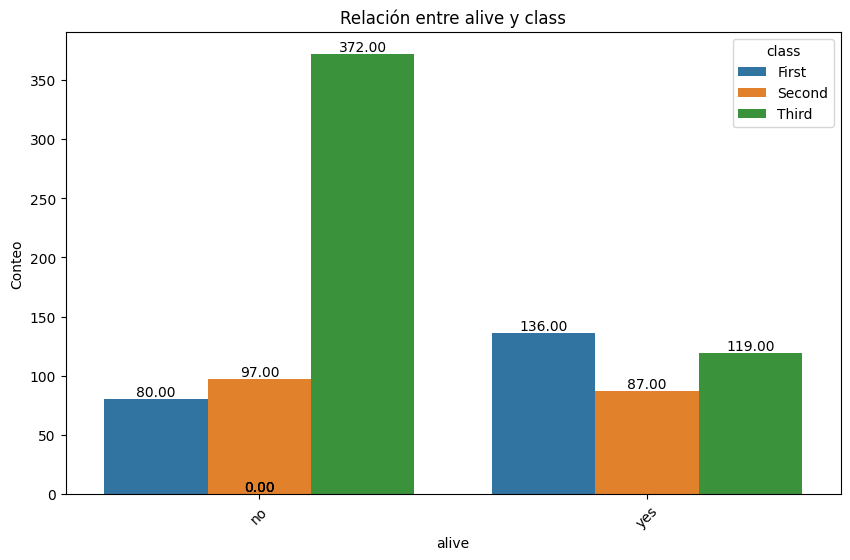

In [104]:
plot_categorical_relationship_fin(df_titanic, "alive", "class", show_values=True)

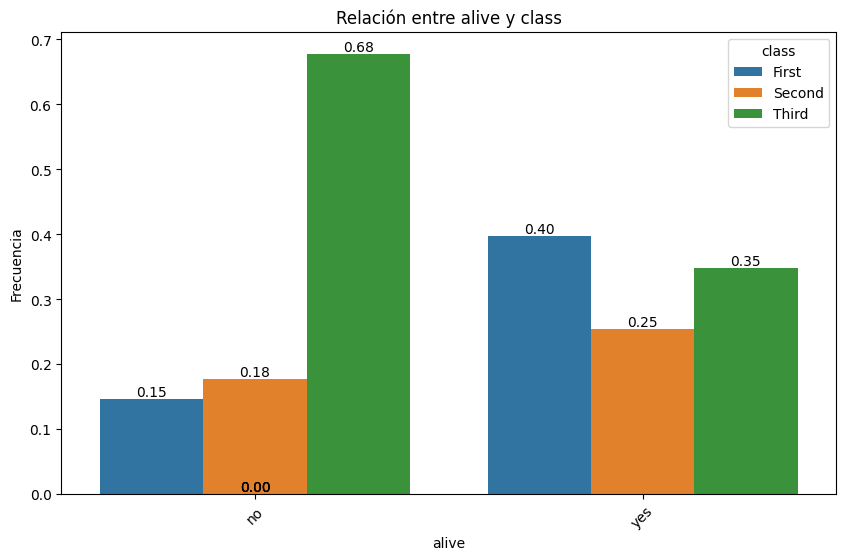

In [105]:
plot_categorical_relationship_fin(df_titanic, "alive", "class",relative_freq=True, show_values=True)

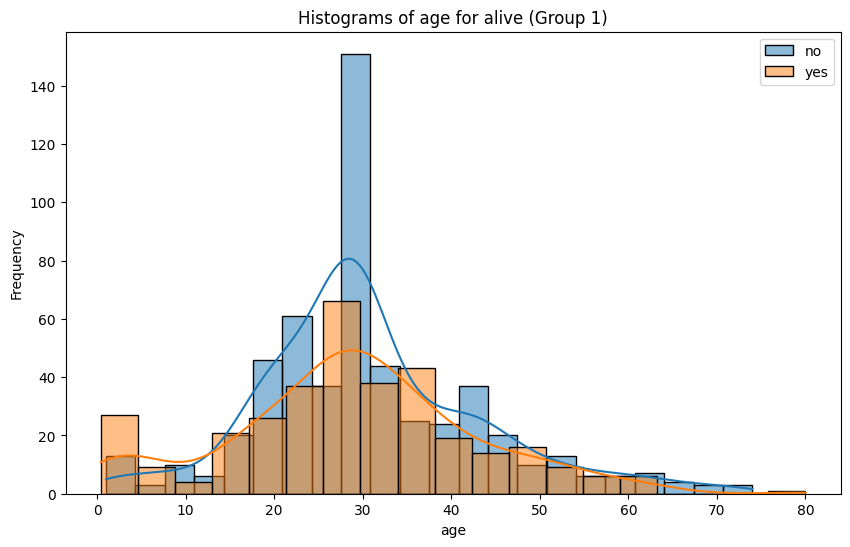

In [106]:
plot_grouped_histograms(df_titanic, "alive", "age" , 2)

Tanto en valores absoluto como relativos la supervivencia fue mayor en los pasajeros de primera clase y en cuanto la edad hubo más supervivencia entre los 26 y 30 años tal y como se observa en el gráfico

### 8

In [107]:
col_directora = "alive"
col_1 = "age"
col_2 = "fare"
diccionario_multivariante = {}

for valor in df_titanic[col_directora].unique():
    diccionario_multivariante[valor] = df_titanic.loc[df_titanic[col_directora] == valor, [col_2, col_1]]

Respuesta no:


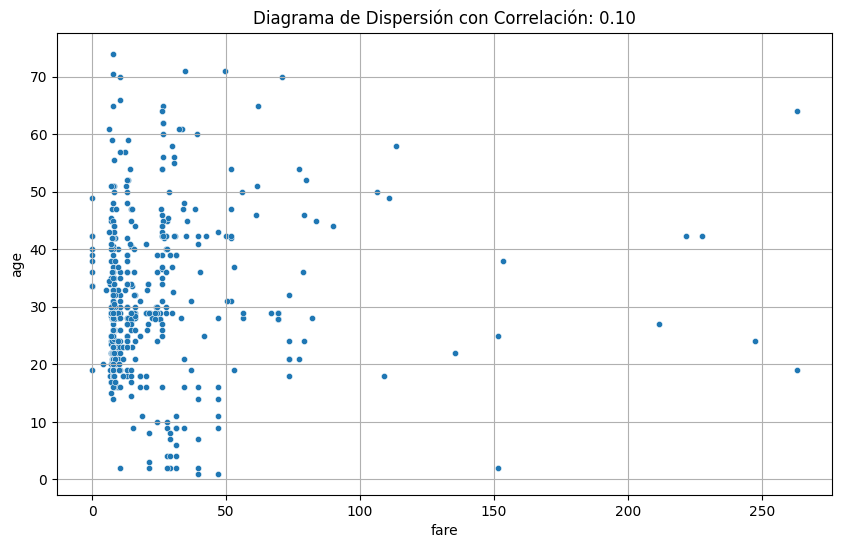

Respuesta yes:


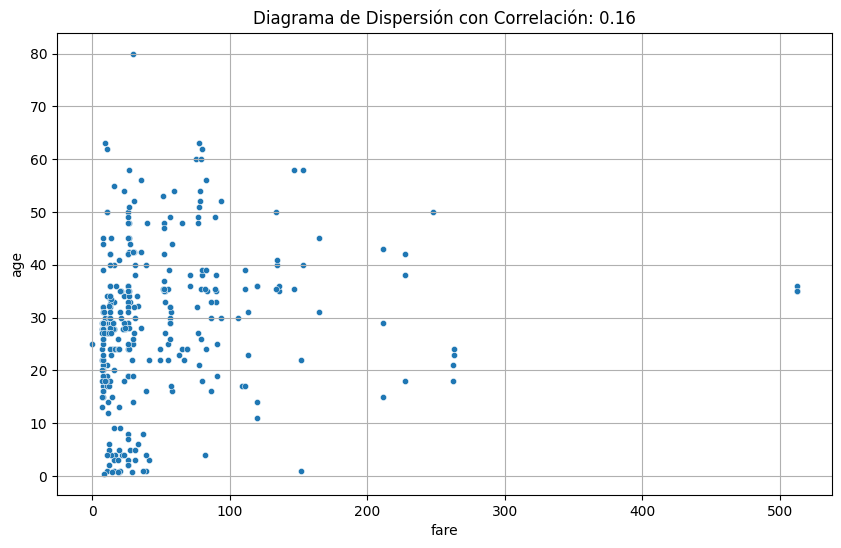

In [108]:
for valor, df_datos in diccionario_multivariante.items():
    print(f"Respuesta {valor}:")
    grafico_dispersion_con_correlacion(df_datos, col_2, col_1, tamano_puntos = 20, mostrar_correlacion=True)

Tal como observamos en las gráficas no existe correlación entre edad, coste del billete y supervivencia.

## #EXTRA: Viajes

El objetivo en este caso no es tanto hacer un montón de análisis sino de completar lo que quedó pendiente en el workout y de entender cómo de un dataset podemos obtener preguntas o hipótesis interesantes (si las hay)

### #EXTRA.1 

Carga el dataset de viajes del mes de junio. Repite el análisis bivariante entre las variables "Aircompany" e "Ingresos", mostrando previamente los viajes por compañía aérea. ¿Qué situación llamativa nos surgió? (Ten en cuenta que somos el departamenteo de DataScience de TabarAir)

In [109]:
df_viajes = pd.read_csv("./data/dataset_viajes_jul.csv")
df_viajes.head(10)

,aircompany,origen,destino,distancia,avion,con_escala,consumo_kg,duracion,ingresos,id_vuelo,mes
0,PamPangea,Nueva York,Londres,5566,Airbus A320,True,15255.96072,523,220563.17,Pam_NuLo_11320,Jul23
1,TabarAir,Cincinnati,Los Angeles,3073,Airbus A380,False,36234.35760,224,192311.81,Tab_CiLo_11380,Jul23
2,FlyQ,Barcelona,Roma,859,Boeing 747,False,9248.50940,77,52866.89,Fly_BaRo_10747,Jul23
3,PamPangea,Ginebra,Bali,12383,Boeing 747,False,138602.91900,845,723138.29,Pam_GiBa_10747,Jul23
4,MoldaviAir,Cádiz,Bali,12798,Airbus A380,False,150903.77760,873,807447.93,Mol_CaBa_11380,Jul23
5,Airnar,Los Angeles,Ginebra,9103,Airbus A320,True,26138.71832,779,347686.57,Air_LoGi_11320,Jul23
6,FlyQ,Roma,Barcelona,859,Airbus A380,False,10724.44320,77,52566.30,Fly_RoBa_11380,Jul23
7,TabarAir,Ginebra,Londres,739,Boeing 747,False,8271.62700,69,45212.09,Tab_GiLo_10747,Jul23
8,MoldaviAir,Londres,Cádiz,1716,Boeing 737,False,4253.27760,150,62944.41,Mol_LoCa_10737,Jul23
9,Airnar,París,Bali,11980,Airbus A380,False,148183.01600,818,778562.65,Air_PaBa_11380,Jul23


In [110]:
df_viajes["aircompany"].value_counts()

aircompany
MoldaviAir    131
TabarAir      129
Airnar        118
PamPangea     114
FlyQ          108
Name: count, dtype: int64

In [111]:
df_viajes.groupby("aircompany")["ingresos"].sum().sort_values(ascending=False)

aircompany
MoldaviAir    69948014.96
PamPangea     63071814.24
Airnar        49026850.10
FlyQ          43794709.73
TabarAir      32730770.05
Name: ingresos, dtype: float64

Lo llamativo era que TabarAir es la segunda compañía en número de vuelos pero la última en ingresos.

### #EXTRA.2

Repite el análisis multivariante entre "ingresos","distancias" y "consumo_kg". ¿Qué veíamos que parecía también muy prometedor?

(3, 2)


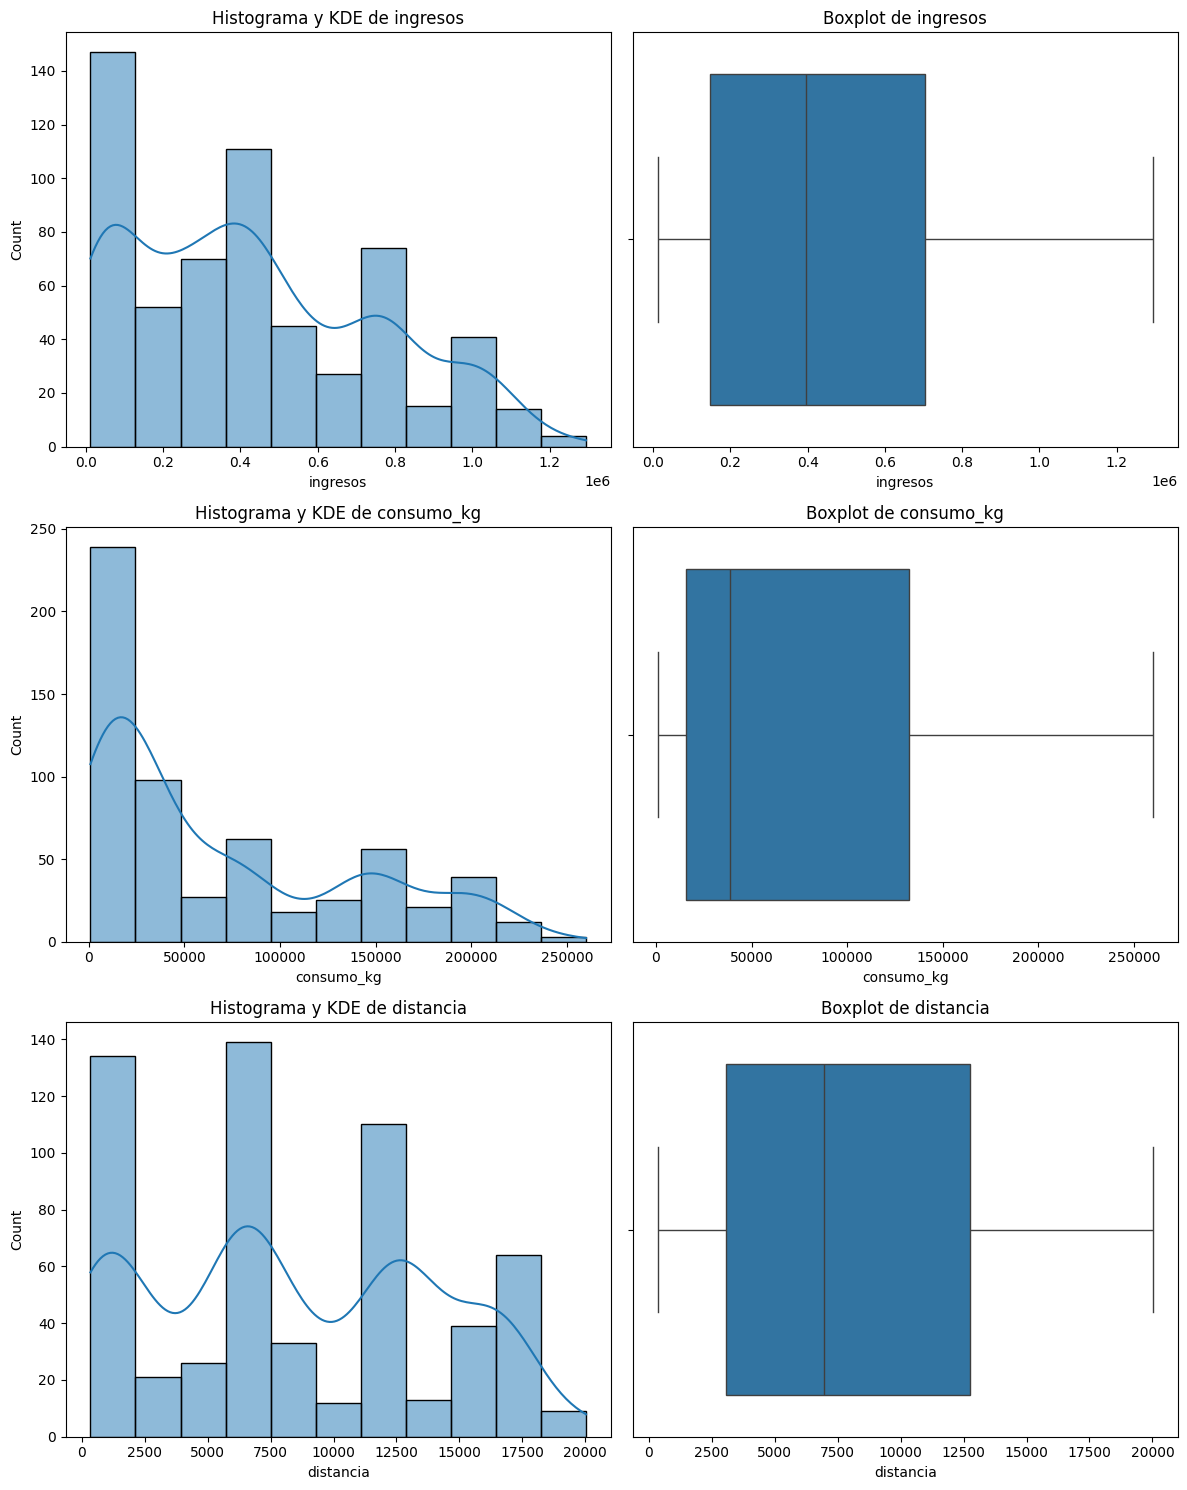

In [112]:
plot_combined_graphs(df_viajes,["ingresos","consumo_kg","distancia"])

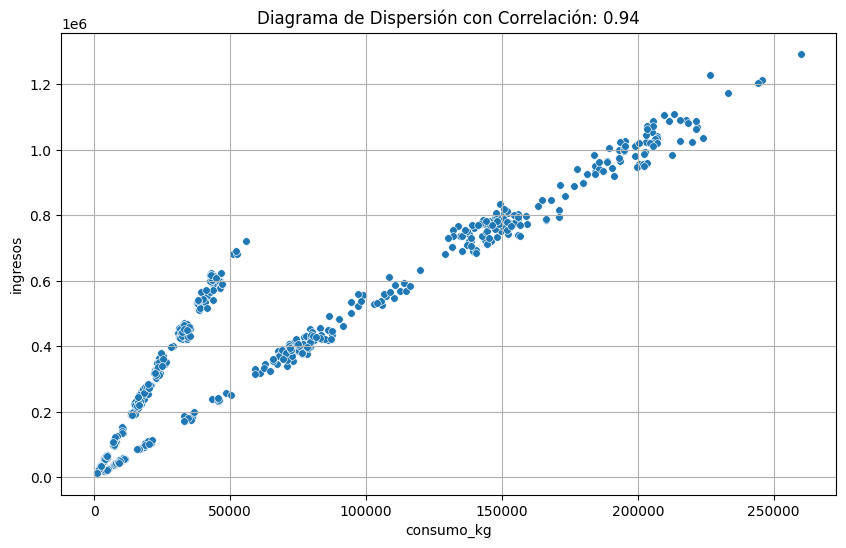

In [113]:
grafico_dispersion_con_correlacion(df_viajes,"consumo_kg","ingresos", mostrar_correlacion=True, tamano_puntos=30)

Ingresos y consumo_kg tiene una clara correlación positiva, con una característica especial que se puede observar y es que hay un grupo de viajes entre 0 y 50000 de conumo_kg que tienen mayores ingresos que otros.

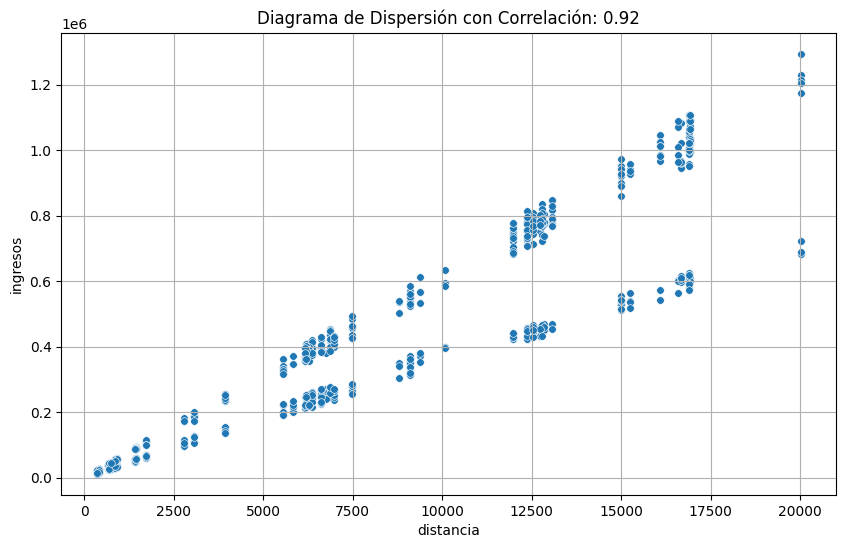

In [114]:
grafico_dispersion_con_correlacion(df_viajes,"distancia","ingresos", mostrar_correlacion=True, tamano_puntos=30)

Entre distancia e ingresos también hay una clara correlación positiva, habiendo también 2 lineas bien difernciadas que nos indica que hay vuelos que a misma distancia tienen más ingresos que otros.

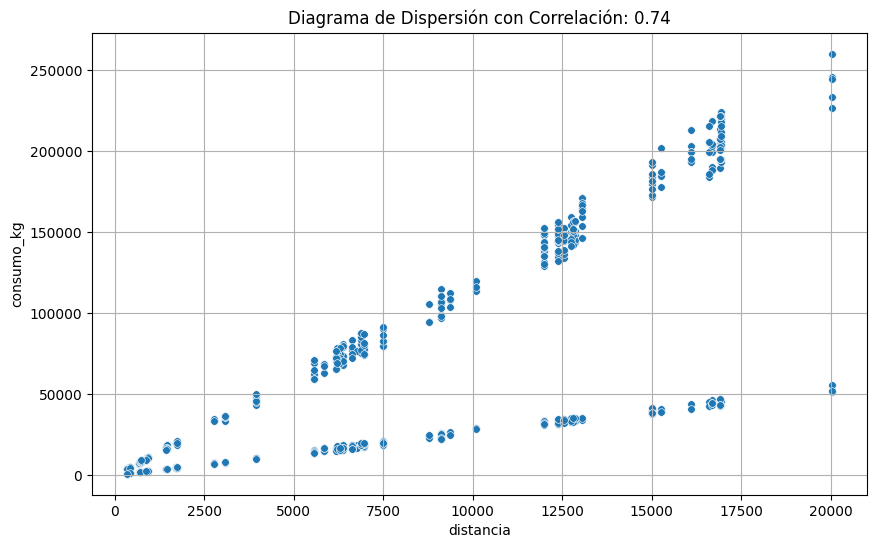

In [115]:
grafico_dispersion_con_correlacion(df_viajes,"distancia","consumo_kg", mostrar_correlacion=True, tamano_puntos=30)

Aquí también podemos observar una correlación positiva entre distancia y consumo_kg, y al igual que en los otros gráficos nos aparecen 2 líneas. Una de ella nos indica que en vuelos de la misma distancia hay unos que consumen menos, por lo tanto más eficientes

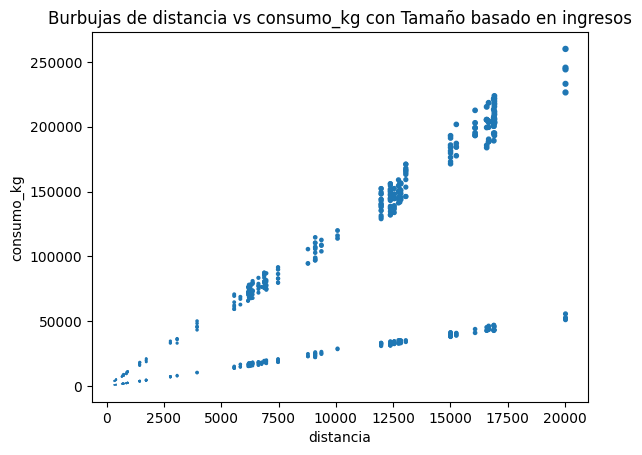

In [116]:
bubble_plot(df_viajes, "distancia", "consumo_kg", "ingresos", scale=100000)

Seguimos viendo la correlación positiva y esa segunda linea que se correspondería a viajes más eficientes.

Por último vamos a calcular la matriz de correlación

In [117]:
corr_matrix = df_viajes.corr(numeric_only=True)
corr_matrix

,distancia,con_escala,consumo_kg,duracion,ingresos
distancia,1.000000,0.689759,0.741539,0.985333,0.920606
con_escala,0.689759,1.000000,0.320797,0.779839,0.524600
consumo_kg,0.741539,0.320797,1.000000,0.642291,0.941690
duracion,0.985333,0.779839,0.642291,1.000000,0.854858
ingresos,0.920606,0.524600,0.941690,0.854858,1.000000


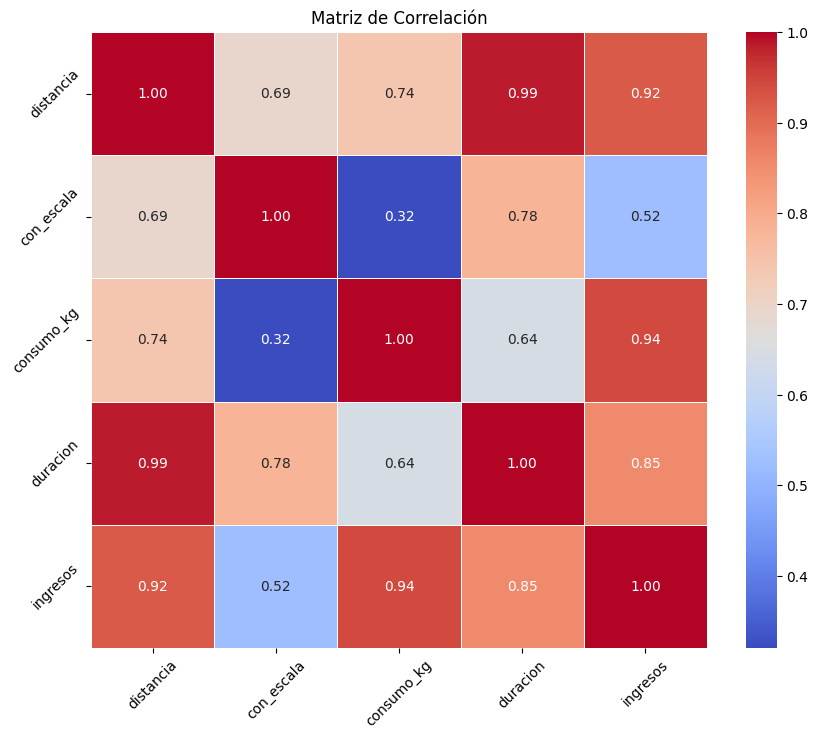

In [118]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,annot=True, fmt=".2f",cmap="coolwarm", cbar=True, square=True, linewidths=.5)
plt.title("Matriz de Correlación")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

Aquí podemos observar claramente la correlación de las variables que estamos analizando.

### #EXTRA.3

Crea una variable categorica "cat_vuelo" a partir de distancias, escoge los rangos de las categorías basándote en la distribución de valores de "distancia" (sugerencia entre 3 y 4 categorías). Extra: Reaiza ahora otra vez el análisis multivariante "cat_vuelo", "ingresos", "consumo_kg". ¿Ves algo diferente?

<Axes: >

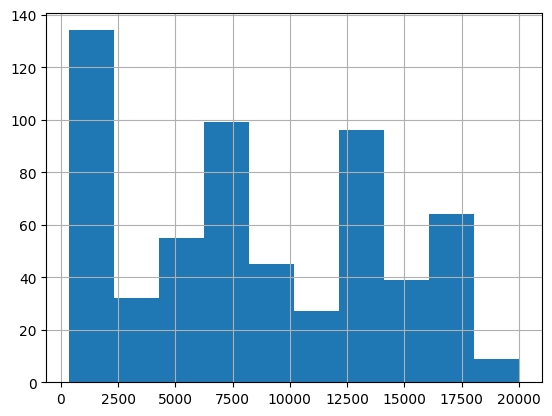

In [119]:
df_viajes["distancia"].hist()


In [120]:
df_viajes["distancia"].describe()

count      600.000000
mean      8392.416667
std       5584.277845
min        344.000000
25%       3073.000000
50%       6969.000000
75%      12738.000000
max      20029.000000
Name: distancia, dtype: float64

In [123]:
df_viajes["cat_vuelo"] = pd.cut(
    df_viajes["distancia"],
    bins=[0, 5000, 10000, 15000, df_viajes['distancia'].max()],
    labels=["corto", "medio", "largo", "ultra"]
)

df_viajes["cat_vuelo"].value_counts()


cat_vuelo
medio    194
corto    166
largo    128
ultra    112
Name: count, dtype: int64

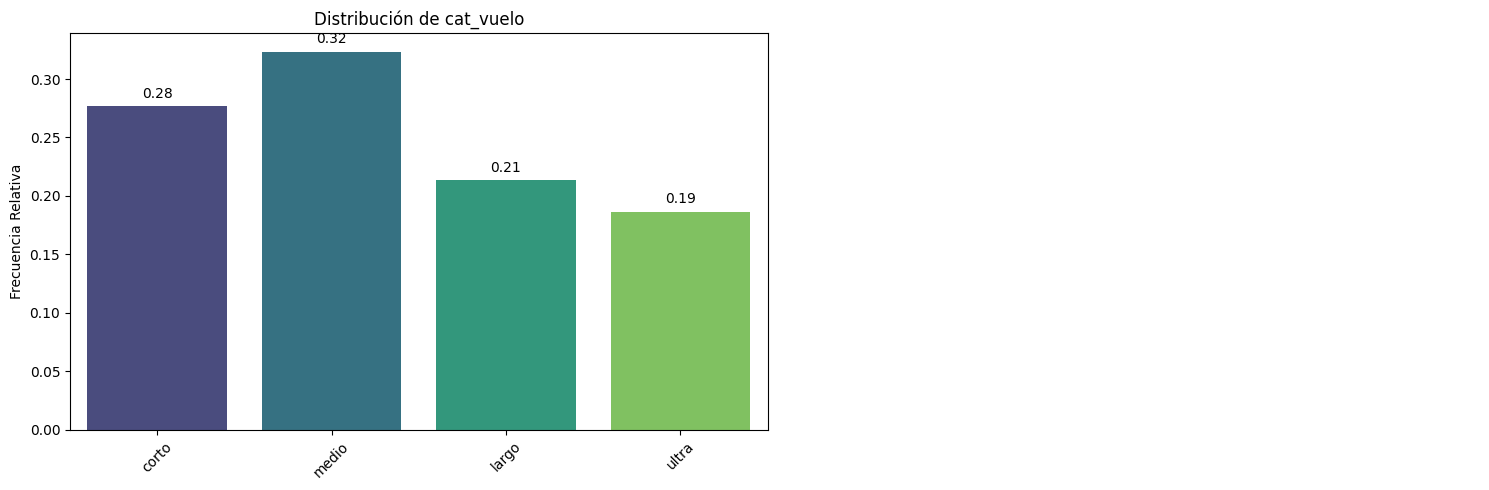

In [125]:
pinta_distribucion_categoricas(df_viajes, ["cat_vuelo"], relativa=True, mostrar_valores=True)

(2,)


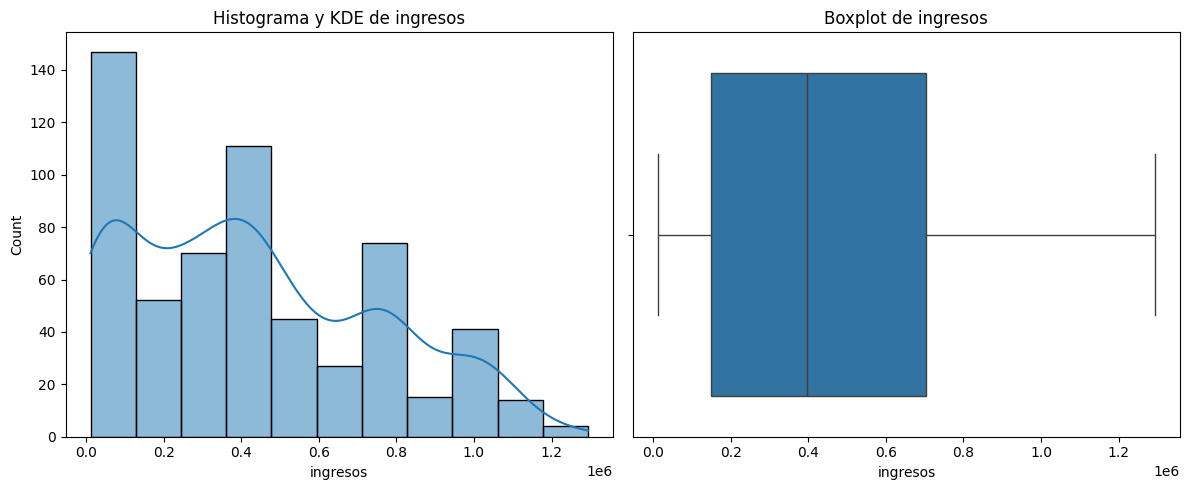

In [126]:
plot_combined_graphs(df_viajes,["ingresos"])

In [127]:
df_viajes["ingresos"].describe()

count    6.000000e+02
mean     4.309536e+05
std      3.188093e+05
min      1.169364e+04
25%      1.480056e+05
50%      3.960467e+05
75%      7.046383e+05
max      1.294102e+06
Name: ingresos, dtype: float64

c:\Users\user\Documents\GitHub\DS-Online-Teresa-Lopez\03_Data_Analysis\Sprint_07\Unidad_02_Estadistica_Descriptiva_Multivariante\03_Practica_Obligatoria\bootcampviztools.py:109: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = df.groupby(categorical_col)[numerical_col].mean()


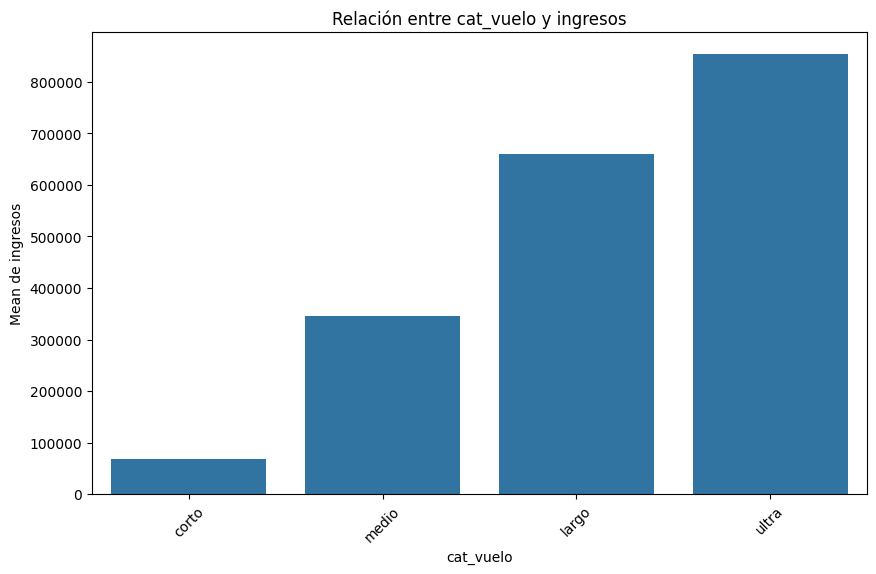

In [ ]:
plot_categorical_numerical_relationship(df_viajes, "cat_vuelo", "ingresos", measure="meddian")

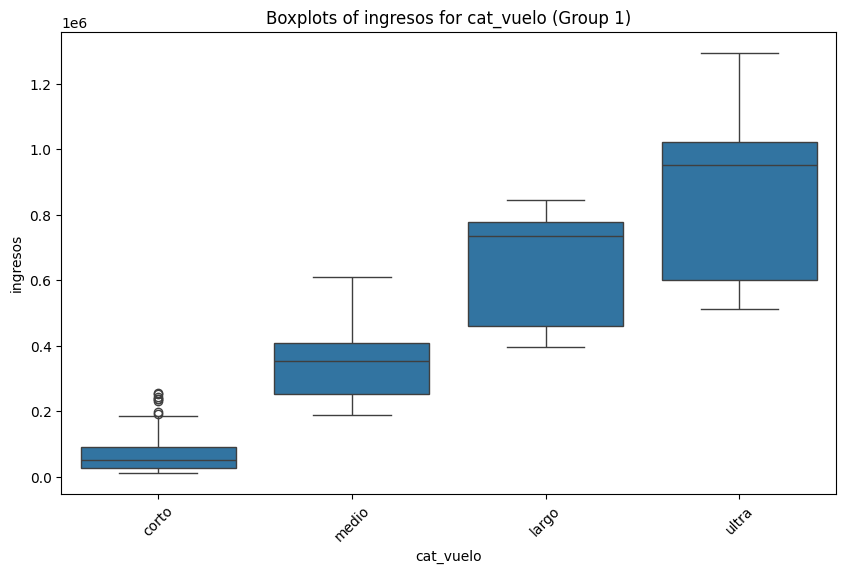

In [130]:
plot_grouped_boxplots(df_viajes, "cat_vuelo", "ingresos")

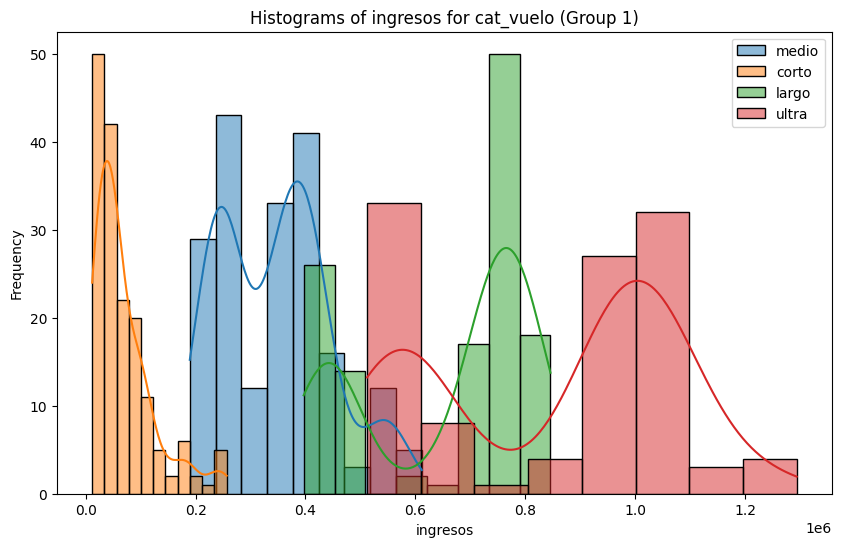

In [131]:
plot_grouped_histograms(df_viajes, "cat_vuelo", "ingresos", 4)

Con los gráficos observados podemos determinar que hay una dependencia entre la categoría de vuelos y los ingresos.

(2,)


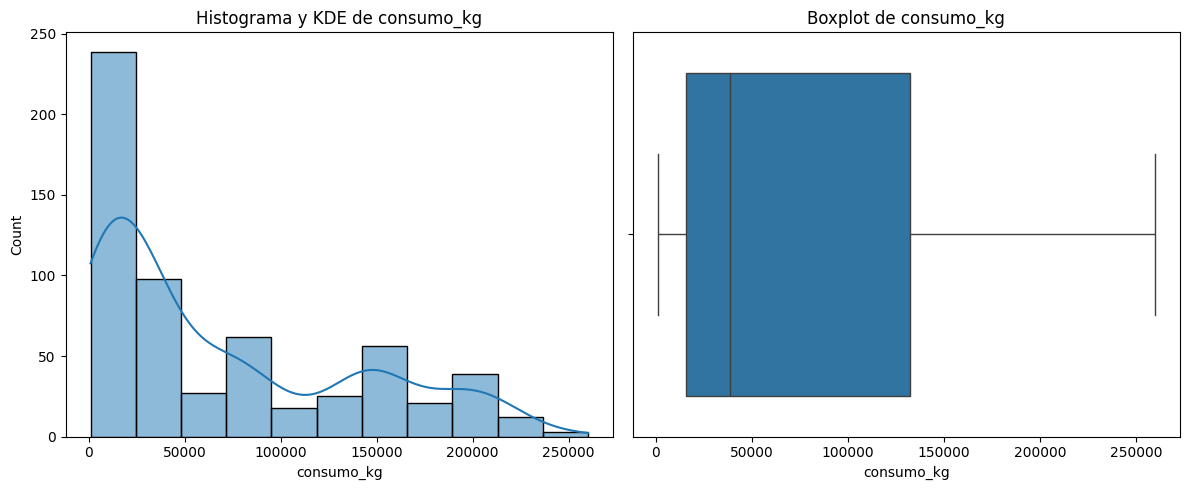

In [134]:
plot_combined_graphs(df_viajes,["consumo_kg"])

In [135]:
df_viajes["consumo_kg"].describe()

count       600.000000
mean      69232.997282
std       67820.805004
min         852.638400
25%       15732.595950
50%       38694.515184
75%      132455.830000
max      260060.381568
Name: consumo_kg, dtype: float64

c:\Users\user\Documents\GitHub\DS-Online-Teresa-Lopez\03_Data_Analysis\Sprint_07\Unidad_02_Estadistica_Descriptiva_Multivariante\03_Practica_Obligatoria\bootcampviztools.py:109: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = df.groupby(categorical_col)[numerical_col].mean()


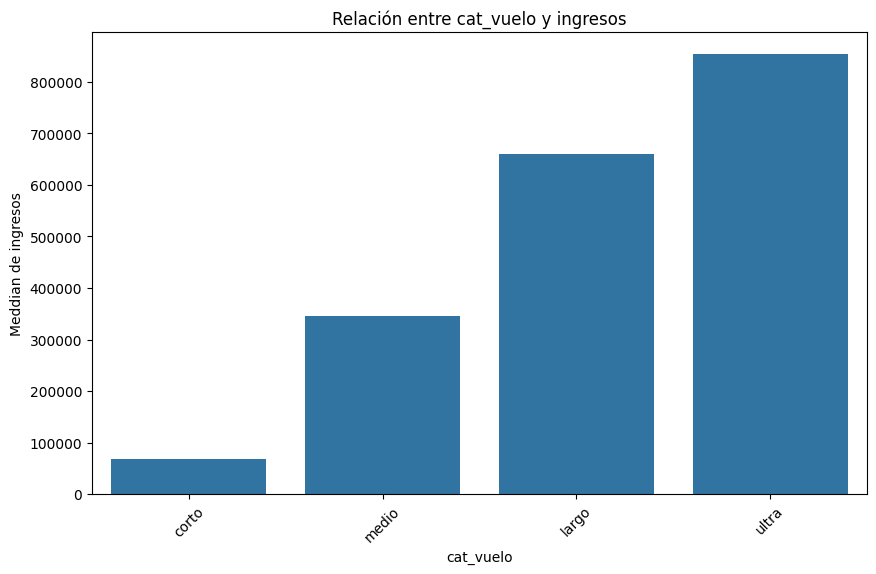

In [136]:
plot_categorical_numerical_relationship(df_viajes, "cat_vuelo", "ingresos", measure="meddian")

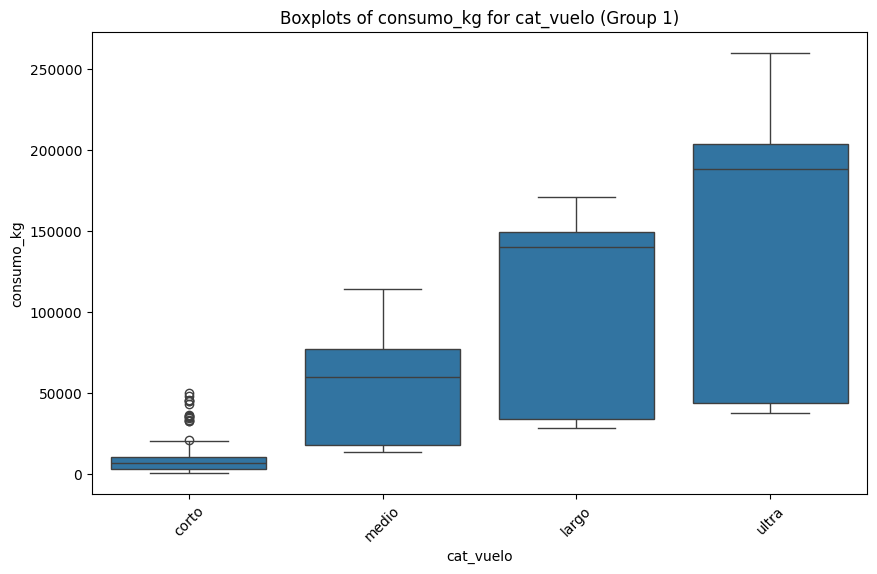

In [138]:
plot_grouped_boxplots(df_viajes, "cat_vuelo", "consumo_kg")

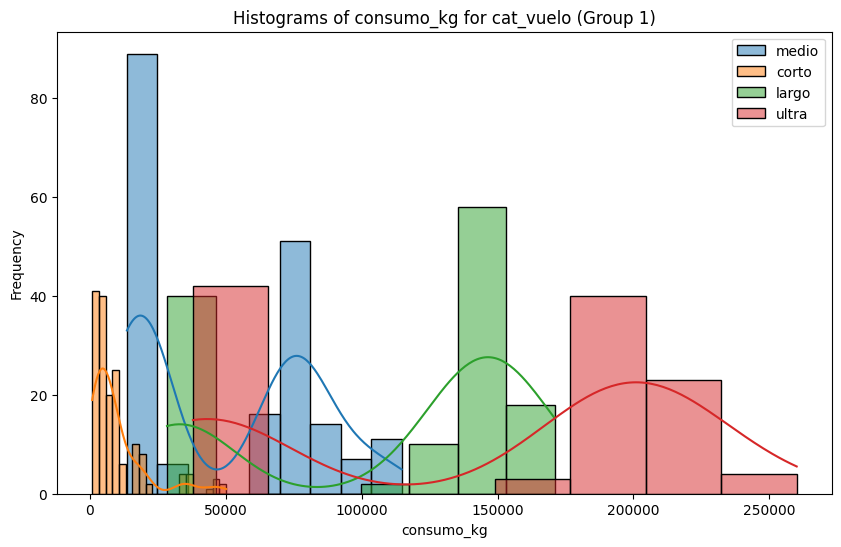

In [139]:
plot_grouped_histograms(df_viajes, "cat_vuelo", "consumo_kg", 4)

Con todos los gráficos observador podemos determinar que también hay dependencia entre cat_vuelo y consumo_kg

In [141]:
col_directora = "cat_vuelo"
col_1 = "ingresos"
col_2 = "consumo_kg"
diccionario_multivariante = {}

for valor in df_viajes[col_directora].unique():
    diccionario_multivariante[valor] = df_viajes.loc[df_viajes[col_directora] == valor, [col_2, col_1]]

Respuesta medio:


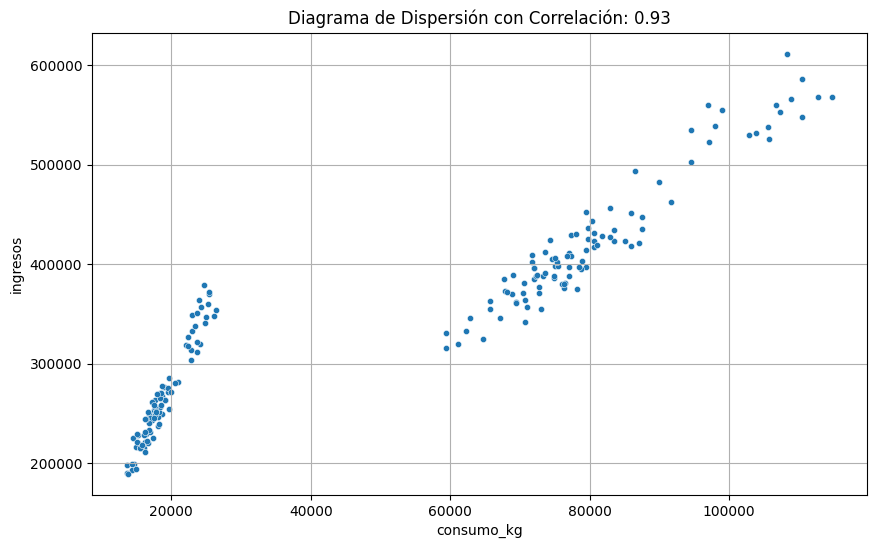

Respuesta corto:


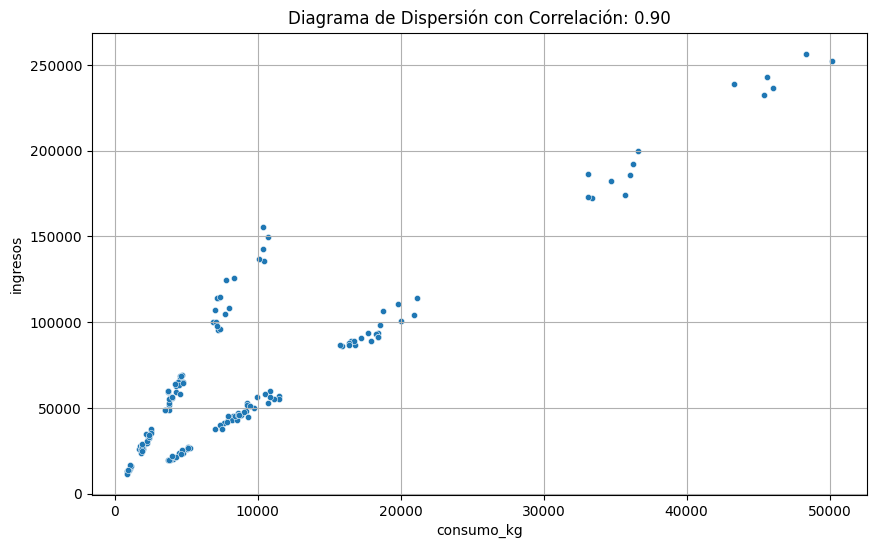

Respuesta largo:


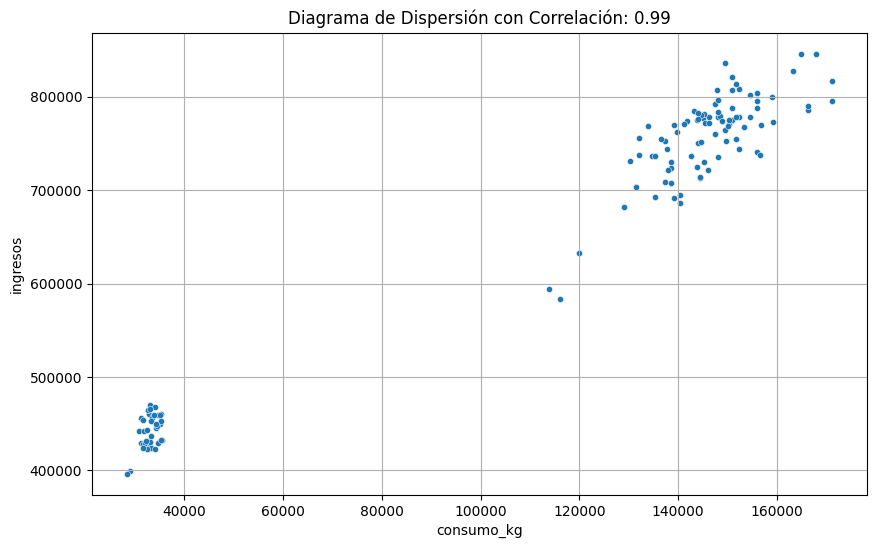

Respuesta ultra:


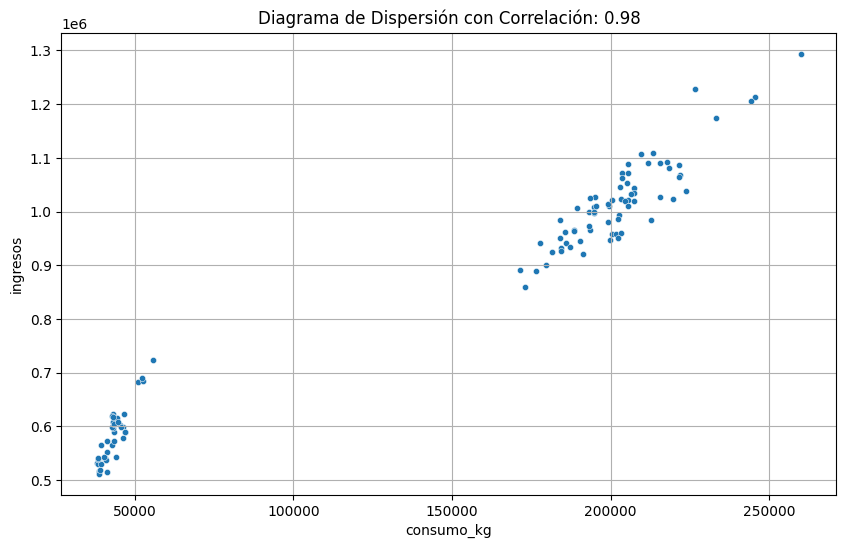

In [142]:
for valor, df_datos in diccionario_multivariante.items():
    print(f"Respuesta {valor}:")
    grafico_dispersion_con_correlacion(df_datos, col_2, col_1, tamano_puntos=20, mostrar_correlacion=True)

Por último podemos observar en todos los casos una correlación positiva de las variables.